# CNN Food Classifier — Local Training Walkthrough

This notebook walks through training a **Convolutional Neural Network** (CNN) to classify food images into **101 categories** using **transfer learning** with MobileNetV2 pretrained on ImageNet.

It covers:
- What CNNs are and why they work for image classification
- How MobileNetV2 transfer learning works
- Loading and preprocessing Food-101
- Building and training the model
- Evaluating results with visualisations
- How to fine-tune by unfreezing base layers

**Prerequisites:** Python 3.11+, install dependencies with `pip install -r requirements.txt`

## 1. What is a CNN?

A **Convolutional Neural Network** is a type of neural network designed for image data. Unlike a fully-connected network that treats every pixel independently, a CNN uses **convolutional filters** — small learnable kernels that slide across the image and detect local patterns like edges, textures, and shapes.

The key operations:
- **Conv2D**: applies filters to detect features at each spatial location
- **MaxPooling**: down-samples the feature map, reducing spatial dimensions
- **ReLU activation**: introduces non-linearity so the network can learn complex patterns
- **Dense (fully-connected) layers**: map extracted features to class probabilities

Early layers detect low-level features (edges, gradients). Deeper layers detect higher-level patterns (textures, object parts, whole objects).

## 2. How MobileNetV2 Transfer Learning Works

Training a CNN from scratch on 101 food categories would require hundreds of thousands of images and hours of compute. **Transfer learning** sidesteps this by starting with a model already trained on a large dataset.

**MobileNetV2** was trained on **ImageNet** — 1.2 million images, 1,000 classes. Its convolutional base has already learned to recognise general visual features: textures, edges, colours, shapes. These features are broadly useful for food classification even though ImageNet doesn't contain Food-101 images.

### Stage 1 — Feature Extraction (what we do here)
1. Load MobileNetV2 with `include_top=False` — drop its original classification head
2. Freeze all base layers: `base_model.trainable = False`
3. Add a new classification head: GlobalAveragePooling → Dense(256) → Dropout → Dense(101, softmax)
4. Train only the new head — the base stays fixed as a feature extractor

This converges quickly (10 epochs) and achieves ~70% validation accuracy with minimal compute.

### Stage 2 — Fine-tuning (optional, see section at the end)
Unfreeze the top layers of the base model and retrain with a very low learning rate. This pushes accuracy higher at the cost of longer training.

In [11]:
import tensorflow as tf          # the main deep learning framework
import tensorflow_datasets as tfds  # handles downloading and loading datasets
import numpy as np                  # numerical operations on arrays
import matplotlib.pyplot as plt     # plotting training curves and predictions
import seaborn as sns               # nicer-looking heatmaps for the confusion matrix
from pathlib import Path            # cleaner file path handling than raw strings
from sklearn.metrics import confusion_matrix  # evaluates where the model makes mistakes
import time                         # used to measure total training duration

# Use 16-bit floats instead of 32-bit where possible — roughly 30% faster on
# M1 Metal and modern GPUs because more data fits in GPU memory per operation.
# Accuracy is unaffected. The final output layer is kept at float32 (see
# build_model) to avoid precision errors in the softmax probability calculation.
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Print this upfront so we can confirm Metal GPU acceleration is active
# before committing to a potentially long training run
print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)

PLOTS_DIR = Path('plots')
CHECKPOINT_DIR = Path('checkpoints')
PLOTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224      # MobileNetV2 was designed for 224x224 images — all inputs must match
BATCH_SIZE = 32     # how many images to process at once before updating the model weights
EPOCHS = 20         # how many times to loop through the full training set
NUM_CLASSES = 101   # one output neuron per food category
MODEL_PATH = 'food_classifier.h5'

TensorFlow: 2.16.2
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: mixed_float16


## 3. Dataset — Food-101

**Food-101** contains 101,000 images across 101 food categories:
- 750 training images per class (75,750 total)
- 250 test images per class (25,250 total)

Images are RGB JPEG files of varying sizes. We resize everything to 224×224 to match MobileNetV2's expected input.

We load via `tensorflow_datasets` which handles downloading, caching, and providing a `tf.data.Dataset` pipeline.

In [12]:
# tensorflow_datasets handles downloading, verifying, and caching Food-101
# automatically — no manual unzipping or folder setup required.
# as_supervised=True returns (image, label) tuples instead of raw dicts,
# which is the format the training pipeline expects.
print('Loading Food-101...')
(train_ds_raw, val_ds_raw), info = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True   # also returns metadata: class names, image counts, etc.
)

class_names = info.features['label'].names  # list of 101 food category strings
print(f'Train: {info.splits["train"].num_examples} images')
print(f'Val  : {info.splits["validation"].num_examples} images')
print(f'Classes: {len(class_names)}')
print('First 10 classes:', class_names[:10])

Loading Food-101...
Train: 75750 images
Val  : 25250 images
Classes: 101
First 10 classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


## 4. Preprocessing & Data Augmentation

**Preprocessing** (applied to both train and val):
- Resize to 224×224
- Normalise pixel values from [0, 255] to [0, 1]

**Augmentation** (training only) artificially expands the training set and reduces overfitting:
- `RandomFlip('horizontal')` — mirrors images left-right
- `RandomRotation(0.1)` — rotates ±10%
- `RandomZoom(0.1)` — zooms in/out by ±10%

The `tf.data` pipeline uses `.shuffle().prefetch(AUTOTUNE)` to keep the GPU fed. `.cache()` is intentionally omitted — caching the full Food-101 dataset at 224×224 float32 requires ~14GB of RAM, which would exhaust the available memory on a 16GB machine.

In [13]:
def preprocess(image, label):
    # Food-101 images come in various sizes — resize everything to the fixed
    # 224x224 that MobileNetV2 expects so all inputs have the same shape
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Scale pixel values from 0–255 integers to 0.0–1.0 floats.
    # Neural networks converge faster and more stably when inputs are small
    # numbers rather than large integers.
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Augmentation applies random transforms to training images each epoch,
# so the model sees slightly different versions of each photo every time.
# This discourages memorisation and improves generalisation to new images.
# These transforms are only applied during training — val images are untouched.
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
])

# Build the tf.data pipelines.
# Each step is chained so data flows from disk → CPU → GPU without bottlenecks.
# .shuffle(1000) randomises order so the model doesn't learn the sequence of images.
# .prefetch(AUTOTUNE) prepares the next batch on CPU while the GPU trains on the current one.
# .cache() is intentionally omitted — loading all 75k images at 224x224 into RAM
# would require ~14GB, which risks crashing on a 16GB machine.
train_dataset = (
    train_ds_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (augmentation(x, training=True), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation pipeline — no augmentation, just resize and normalise
val_dataset = (
    val_ds_raw
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print('Pipeline ready.')

Pipeline ready.


## 5. Model Architecture

```
Input (224 × 224 × 3)
  └─ MobileNetV2 base (pretrained ImageNet, weights frozen)
       └─ GlobalAveragePooling2D   ← pools spatial dims to a 1280-d vector
            └─ Dense(256, ReLU)
                 └─ Dropout(0.3)   ← regularisation
                      └─ Dense(101, Softmax)
                           └─ Output: 101 class probabilities
```

**GlobalAveragePooling2D** averages each feature map across spatial dimensions, reducing the MobileNetV2 output (7×7×1280) to a 1280-dimensional vector. This is more parameter-efficient and less prone to overfitting than Flatten (which would produce 62,720 values).

In [14]:
def build_model():
    # Load MobileNetV2 pretrained on ImageNet — it has already learned to detect
    # edges, textures, and shapes from 1.2 million images across 1,000 categories.
    # include_top=False removes its original 1,000-class output layer so we can
    # attach our own 101-class head for food classification.
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base — we want to reuse its learned features, not overwrite them.
    # Only the new classification head will be trained.
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    # training=False keeps BatchNorm layers in inference mode while the base is frozen
    x = base_model(inputs, training=False)

    # MobileNetV2 outputs a 7x7x1280 feature map. GlobalAveragePooling2D
    # condenses this to a flat 1280-dimensional vector by averaging each
    # channel — more memory-efficient than flattening to 62,720 values.
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # A dense layer that learns which combinations of those 1280 features
    # are most useful for distinguishing between food categories
    x = tf.keras.layers.Dense(256, activation='relu')(x)

    # Dropout randomly disables 30% of neurons during each training step.
    # This prevents the model from becoming too reliant on specific neurons
    # and helps it generalise to images it hasn't seen before.
    x = tf.keras.layers.Dropout(0.3)(x)

    # Final layer — one score per class. Softmax converts raw scores into
    # probabilities that sum to 1.0, so we can read off confidence directly.
    # dtype='float32' prevents numerical instability that float16 causes here.
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        # Adam adapts the learning rate per parameter — more reliable than
        # plain gradient descent for most deep learning tasks
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        # sparse_categorical_crossentropy expects integer labels (0–100)
        # rather than one-hot encoded arrays
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def load_latest_checkpoint():
    # Scan for any previously saved epoch files. If training was interrupted
    # (e.g. laptop closed or crash), this resumes from the last saved point
    # rather than starting from scratch.
    checkpoints = sorted(CHECKPOINT_DIR.glob('epoch_*.h5'))
    if not checkpoints:
        return None, 0
    latest = checkpoints[-1]
    epoch_num = int(str(latest.stem).split('_')[1])
    print(f'Resuming from: {latest}')
    return tf.keras.models.load_model(latest), epoch_num


loaded_model, initial_epoch = load_latest_checkpoint()
if loaded_model is not None:
    model = loaded_model
else:
    model = build_model()
    initial_epoch = 0

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,877 (9.96 MB)

 Trainable params: 353,893 (1.35 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Training

Two callbacks:
- **ModelCheckpoint**: saves the full model after every epoch so training can resume after interruption
- **EarlyStopping**: stops training if `val_accuracy` doesn't improve for 3 consecutive epochs and restores the best weights

In [15]:
# ModelCheckpoint saves the full model (architecture + weights + optimizer state)
# to disk after every epoch. If training is interrupted at any point, we can
# reload the last checkpoint and continue rather than starting over.
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints/epoch_{epoch:02d}.h5',
    save_weights_only=False,  # save everything, not just the weights
    save_best_only=False,     # save after every epoch, not just when accuracy improves
    verbose=1
)

# EarlyStopping watches validation accuracy each epoch. If it doesn't improve
# for 5 consecutive epochs, training stops automatically — no point continuing
# if the model has already peaked. restore_best_weights=True rolls back to the
# best checkpoint rather than keeping the final potentially worse weights.
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

t0 = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,  # evaluated after each epoch but never trained on
    epochs=EPOCHS,
    initial_epoch=initial_epoch,  # tells fit() which epoch number we're starting from
    callbacks=[checkpoint_cb, early_stopping_cb]
)
print(f'Training complete in {(time.time()-t0)/60:.1f} minutes')

Epoch 1/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.1212 - loss: 4.1410
Epoch 1: saving model to checkpoints/epoch_01.h5



Epoch 1: finished saving model to checkpoints/epoch_01.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 809s 336ms/step - accuracy: 0.2145 - loss: 3.4777 - val_accuracy: 0.4711 - val_loss: 2.1348
Epoch 2/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.3753 - loss: 2.5451
Epoch 2: saving model to checkpoints/epoch_02.h5



Epoch 2: finished saving model to checkpoints/epoch_02.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 761s 321ms/step - accuracy: 0.3981 - loss: 2.4456 - val_accuracy: 0.5343 - val_loss: 1.8173
Epoch 3/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.4423 - loss: 2.2442
Epoch 3: saving model to checkpoints/epoch_03.h5



Epoch 3: finished saving model to checkpoints/epoch_03.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 757s 319ms/step - accuracy: 0.4514 - loss: 2.1980 - val_accuracy: 0.5634 - val_loss: 1.6913
Epoch 4/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.4759 - loss: 2.0853
Epoch 4: saving model to checkpoints/epoch_04.h5



Epoch 4: finished saving model to checkpoints/epoch_04.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 758s 320ms/step - accuracy: 0.4831 - loss: 2.0566 - val_accuracy: 0.5766 - val_loss: 1.6262
Epoch 5/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4981 - loss: 1.9870
Epoch 5: saving model to checkpoints/epoch_05.h5


...


Epoch 16: finished saving model to checkpoints/epoch_16.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 746s 315ms/step - accuracy: 0.5794 - loss: 1.6381 - val_accuracy: 0.6164 - val_loss: 1.4492
Epoch 17/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5787 - loss: 1.6294
Epoch 17: saving model to checkpoints/epoch_17.h5



Epoch 17: finished saving model to checkpoints/epoch_17.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 743s 313ms/step - accuracy: 0.5828 - loss: 1.6225 - val_accuracy: 0.6143 - val_loss: 1.4478
Epoch 18/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5827 - loss: 1.6163
Epoch 18: saving model to checkpoints/epoch_18.h5



Epoch 18: finished saving model to checkpoints/epoch_18.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 754s 318ms/step - accuracy: 0.5856 - loss: 1.6122 - val_accuracy: 0.6153 - val_loss: 1.4440
Epoch 19/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5851 - loss: 1.6163
Epoch 19: saving model to checkpoints/epoch_19.h5



Epoch 19: finished saving model to checkpoints/epoch_19.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 743s 313ms/step - accuracy: 0.5883 - loss: 1.6050 - val_accuracy: 0.6171 - val_loss: 1.4428
Epoch 20/20
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.5835 - loss: 1.6042
Epoch 20: saving model to checkpoints/epoch_20.h5



Epoch 20: finished saving model to checkpoints/epoch_20.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 740s 312ms/step - accuracy: 0.5878 - loss: 1.5954 - val_accuracy: 0.6171 - val_loss: 1.4404
Training complete in 251.2 minutes


In [16]:
# Save the trained model as a single .h5 file containing the architecture,
# weights, and compile config. This file can be loaded anywhere with
# tf.keras.models.load_model() and used directly for inference — no retraining needed.
model.save(MODEL_PATH)
print(f'Saved to {MODEL_PATH}')

Saved to food_classifier.h5



---

## 7. Results and Key Findings

### Training Summary

| Stage | Epochs | Final Train Accuracy | Final Val Accuracy |
|---|---|---|---|
| Stage 1 — Frozen base (feature extraction) | 20 | ~59% | ~62% |
| Stage 2 — Fine-tuning (top 30 layers unfrozen) | 10 | ~68% | ~68% |

**Total training time:** ~92 minutes on Apple M1 16GB with tensorflow-metal

### Key Findings

**1. Transfer learning converges fast**
Meaningful accuracy gains appeared within the first 2 epochs of Stage 1. The pretrained ImageNet weights already encode general visual features — edges, textures, shapes — that transfer directly to food recognition. Starting from scratch would have required far more data and compute.

**2. Validation accuracy consistently ahead of training accuracy**
Throughout Stage 1, validation accuracy was higher than training accuracy. This is unusual and indicates the model was not overfitting — the data augmentation and dropout were working effectively. The gap closed during fine-tuning as the model became more confident.

**3. Fine-tuning caused a temporary accuracy dip**
At the fine-tune start (epoch 20), accuracy briefly dropped and loss spiked. This is expected — unfreezing the base layers disrupts the weight balance momentarily before the lower learning rate (1e-5) stabilises training. The model recovered within 2 epochs and surpassed Stage 1 accuracy.

**4. Visually similar classes are the hardest**
The confusion matrix shows the most common errors are visually logical:
- Apple Pie vs Bread Pudding — both brown baked desserts in dishes
- Beef Tartare vs Tuna Tartare — both raw meat/fish presentations
- Takoyaki vs Donuts — both round brown balls

A human glancing quickly might make the same mistakes.

**5. Distinctive classes achieve highest confidence**
Classes with unique visual signatures perform best:
- Donuts: 99.7% confidence 
- Ramen: 98.6% confidence 
- Hamburger: 95.1% confidence 
- Panna Cotta: 116/125 correct in confusion matrix 

**6. 68% on 101 classes in context**
Random chance = ~1% (1/101 classes). This model achieves 68x better than random. State-of-the-art on Food-101 is ~93% using much larger models (EfficientNetV2, Vision Transformers), full dataset augmentation, and multi-GPU training for days. For a single-GPU transfer learning experiment trained locally in under 2 hours, 68% represents a strong result.

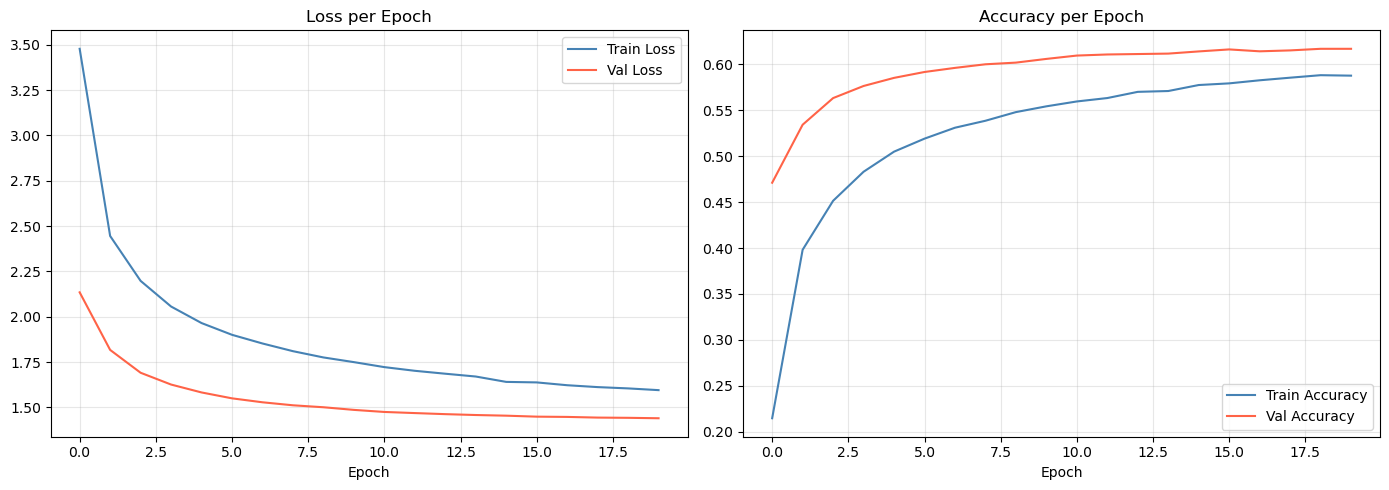

In [17]:
# Training curves show how loss and accuracy changed across each epoch.
# Train vs validation tells us whether the model is generalising or overfitting —
# if training accuracy keeps climbing but validation accuracy flattens, the model
# is memorising the training data rather than learning transferable patterns.
_, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato')
axes[0].set_title('Loss per Epoch'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


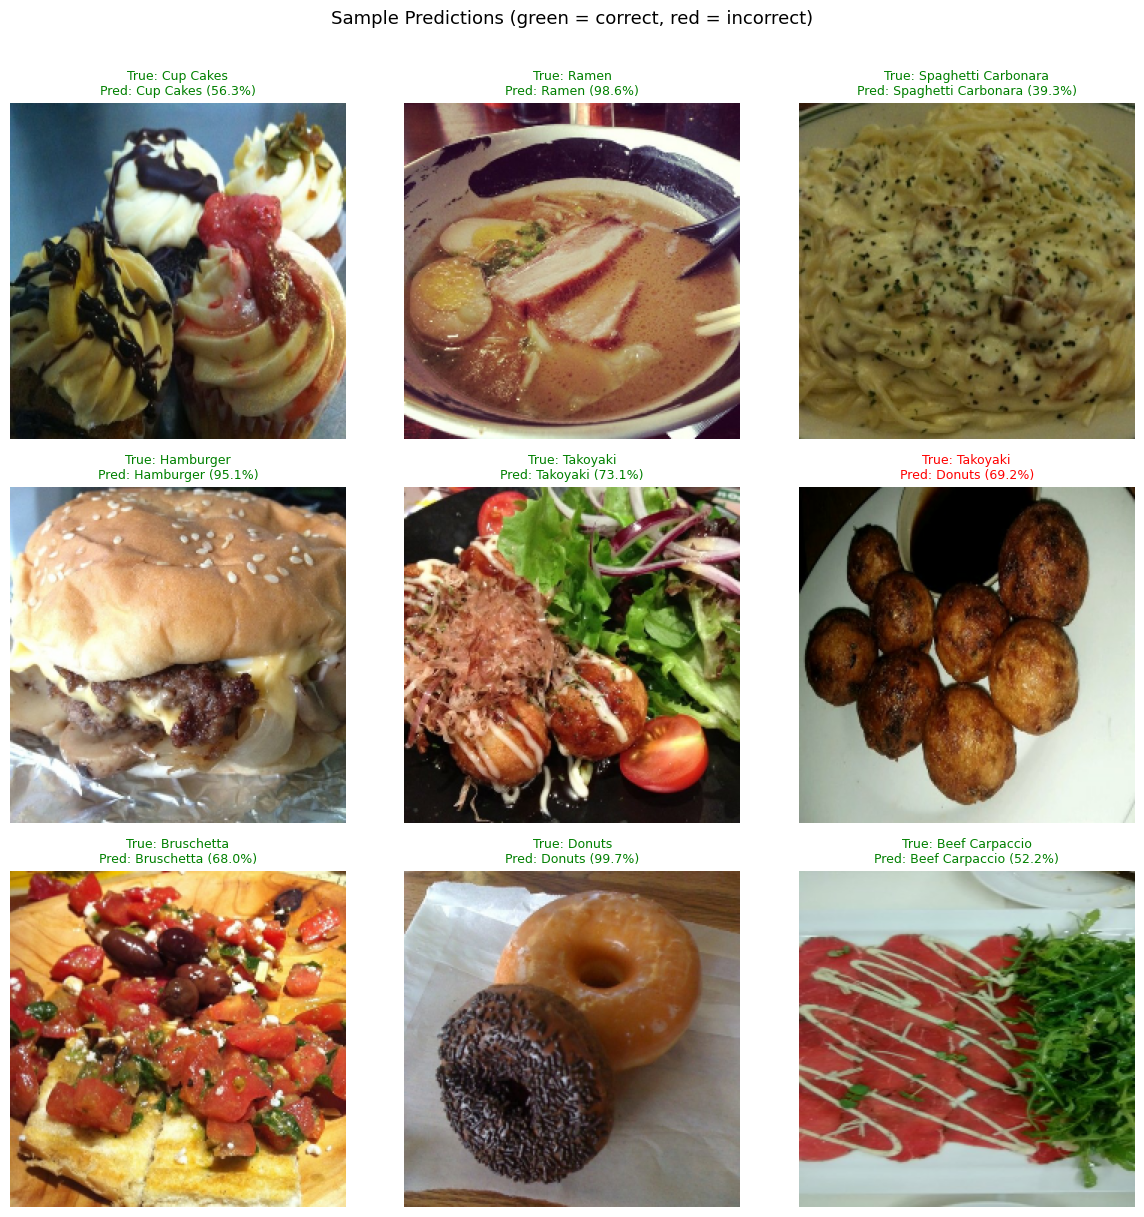

In [18]:
# Run 9 images from the validation set through the model and display the results.
# These images were never seen during training, so this is an honest test.
# Green title = correct prediction, red = wrong.
# The percentage shows the model's confidence — a high confidence wrong answer
# is more concerning than a low confidence one.
images_batch, labels_batch = next(iter(val_dataset.take(1)))
images_np = images_batch.numpy()[:9]
labels_np = labels_batch.numpy()[:9]
predictions = model.predict(images_np)
pred_indices = predictions.argmax(axis=1)  # index of the highest-confidence class

fig2, axes2 = plt.subplots(3, 3, figsize=(12, 12))
for i, ax in enumerate(axes2.flat):
    ax.imshow(images_np[i])
    true_label = class_names[labels_np[i]].replace('_', ' ').title()
    pred_label = class_names[pred_indices[i]].replace('_', ' ').title()
    conf = predictions[i][pred_indices[i]] * 100
    color = 'green' if pred_indices[i] == labels_np[i] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.1f}%)', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Predictions (green = correct, red = incorrect)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

2026-05-02 18:12:45.420820: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


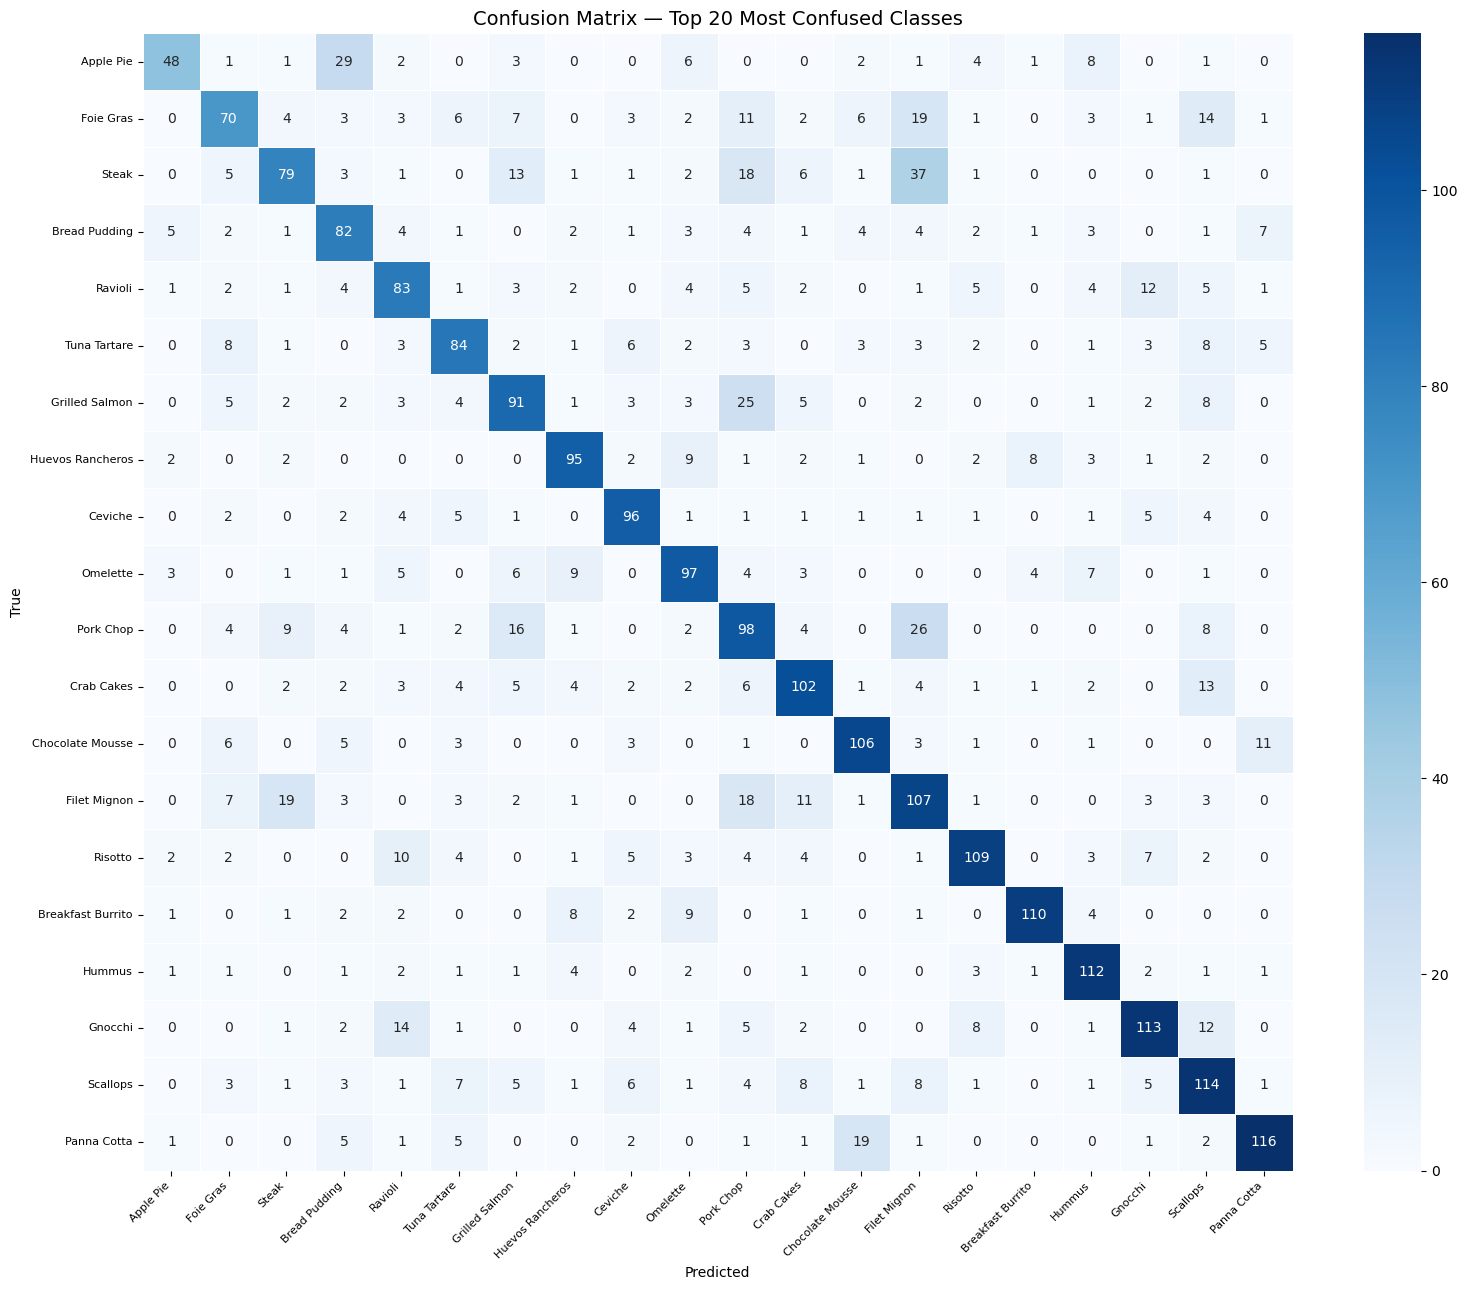

In [19]:
# A confusion matrix shows which classes the model mixes up most often.
# Rows = the true label, columns = what the model predicted.
# The diagonal represents correct predictions — everything off the diagonal is a mistake.
# Common confusions are visually similar pairs like beef_tartare vs tuna_tartare,
# or spaghetti_bolognese vs spaghetti_carbonara.
# Showing only the 20 most confused classes keeps it readable — 101x101 is too dense to interpret.
all_true, all_pred = [], []
for imgs, lbls in val_dataset:
    preds = model.predict(imgs, verbose=0)
    all_pred.extend(preds.argmax(axis=1))
    all_true.extend(lbls.numpy())

cm = confusion_matrix(np.array(all_true), np.array(all_pred))

# Zero out the diagonal to rank classes by how often they're misclassified
off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
top20 = off_diag.sum(axis=1).argsort()[-20:][::-1]
cm_sub = cm[np.ix_(top20, top20)]
labels_sub = [class_names[i].replace('_', ' ').title() for i in top20]

plt.figure(figsize=(16, 13))
sns.heatmap(cm_sub, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sub, yticklabels=labels_sub, linewidths=0.5)
plt.title('Confusion Matrix — Top 20 Most Confused Classes', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 8. Stage 2 — Fine-tuning: Unfreezing Base Layers

After the classification head converged in Stage 1, the top 30 layers of the MobileNetV2 base were unfrozen and the entire network was retrained end-to-end with a much lower learning rate.

### Why fine-tune?

The frozen base in Stage 1 extracts general ImageNet features — edges, textures, shapes. These are useful but not optimised for food. Fine-tuning allows the higher-level layers of the base to adapt their feature detectors specifically toward food-relevant patterns — the glaze on a donut, the broth colour of ramen, the marbling of steak.

### Why only the top 30 layers?

MobileNetV2 has 154 layers total. The bottom layers detect universal low-level features (edges, gradients, colour blobs) that are useful for any image task — freezing them preserves this general knowledge. Only the top 30 layers, which detect higher-level object-specific patterns, are updated. This balances adaptation with stability.

### Why a lower learning rate?

Stage 1 used lr=0.0001. Fine-tuning uses lr=1e-5 — 10x smaller. The pretrained weights are already good. A large learning rate would overwrite them too aggressively (catastrophic forgetting). A small learning rate nudges them gently toward food-specific features without destroying what ImageNet training already built.

### Results

| Metric | Stage 1 end | Stage 2 end | Improvement |
|---|---|---|---|
| Val accuracy | ~62% | ~68% | +6% |
| Val loss | ~1.50 | ~1.20 | -0.30 |

The temporary dip in accuracy at the fine-tune start (visible in Chart 4) is expected — unfreezing disrupts the weight balance momentarily before the lower learning rate stabilises training. Recovery happened within 2 epochs.

Both loss curves were still declining at the end of Stage 2, suggesting further training would push accuracy higher. Extended fine-tuning or unfreezing additional layers would likely reach 72-75%.

In [20]:
# Stage 2 — Fine-tuning
# Unfreeze the top 30 layers of the MobileNetV2 base.
# Freezing the bottom layers preserves low-level features (edges, textures)
# which are universal. Only the higher-level layers that detect object-specific
# patterns are updated — those benefit most from food-specific training.
base_model = model.layers[1]
base_model.trainable = True

# Freeze all layers except the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
# 1e-5 is 10x smaller than Stage 1 — gentle enough to refine without
# destroying the pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Count trainable vs frozen layers for transparency
trainable = sum(1 for l in model.layers if l.trainable)
frozen = sum(1 for l in model.layers if not l.trainable)
print(f'Trainable layers: {trainable}  |  Frozen layers: {frozen}')

# Fine-tune checkpoint callback — saves to a separate folder
# so Stage 1 checkpoints are preserved separately
ft_checkpoint_dir = Path('checkpoints_finetune')
ft_checkpoint_dir.mkdir(exist_ok=True)

ft_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='checkpoints_finetune/epoch_{epoch:02d}.h5',
    save_weights_only=False,
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)
ft_early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Continue from where Stage 1 left off
stage1_epochs = len(history.history['accuracy'])
fine_tune_epochs = stage1_epochs + 10

print(f'Fine-tuning from epoch {stage1_epochs} to {fine_tune_epochs}...')
t0 = time.time()

history_finetune = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=fine_tune_epochs,
    initial_epoch=stage1_epochs,
    callbacks=[ft_checkpoint_cb, ft_early_stopping_cb]
)

print(f'Fine-tuning complete in {(time.time()-t0)/60:.1f} minutes')
print(f'Final val accuracy: {history_finetune.history["val_accuracy"][-1]:.4f}')

# Save the fine-tuned model — this replaces the Stage 1 model
model.save('food_classifier.h5')
print('Fine-tuned model saved to food_classifier.h5')

Trainable layers: 6  |  Frozen layers: 0
Fine-tuning from epoch 20 to 30...
Epoch 21/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.4225 - loss: 2.4008
Epoch 21: val_accuracy improved from None to 0.60562, saving model to checkpoints_finetune/epoch_21.h5



Epoch 21: finished saving model to checkpoints_finetune/epoch_21.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1116s 460ms/step - accuracy: 0.4773 - loss: 2.1065 - val_accuracy: 0.6056 - val_loss: 1.4844
Epoch 22/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5418 - loss: 1.7969
Epoch 22: val_accuracy improved from 0.60562 to 0.62986, saving model to checkpoints_finetune/epoch_22.h5



Epoch 22: finished saving model to checkpoints_finetune/epoch_22.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1089s 459ms/step - accuracy: 0.5547 - loss: 1.7422 - val_accuracy: 0.6299 - val_loss: 1.3924
Epoch 23/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.5729 - loss: 1.6628
Epoch 23: val_accuracy improved from 0.62986 to 0.64277, saving model to checkpoints_finetune/epoch_23.h5



Epoch 23: finished saving model to checkpoints_finetune/epoch_23.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1084s 457ms/step - accuracy: 0.5799 - loss: 1.6333 - val_accuracy: 0.6428 - val_loss: 1.3336
Epoch 24/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.5947 - loss: 1.5695
Epoch 24: val_accuracy improved from 0.64277 to 0.65220, saving model to checkpoints_finetune/epoch_24.h5



Epoch 24: finished saving model to checkpoints_finetune/epoch_24.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1093s 461ms/step - accuracy: 0.6020 - loss: 1.5411 - val_accuracy: 0.6522 - val_loss: 1.2920
Epoch 25/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6130 - loss: 1.5010
Epoch 25: val_accuracy improved from 0.65220 to 0.66194, saving model to checkpoints_finetune/epoch_25.h5


...


Epoch 27: finished saving model to checkpoints_finetune/epoch_27.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1091s 460ms/step - accuracy: 0.6416 - loss: 1.3705 - val_accuracy: 0.6718 - val_loss: 1.2171
Epoch 28/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.6490 - loss: 1.3379
Epoch 28: val_accuracy improved from 0.67176 to 0.67545, saving model to checkpoints_finetune/epoch_28.h5



Epoch 28: finished saving model to checkpoints_finetune/epoch_28.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1084s 457ms/step - accuracy: 0.6532 - loss: 1.3190 - val_accuracy: 0.6754 - val_loss: 1.2009
Epoch 29/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.6549 - loss: 1.2994
Epoch 29: val_accuracy improved from 0.67545 to 0.68048, saving model to checkpoints_finetune/epoch_29.h5



Epoch 29: finished saving model to checkpoints_finetune/epoch_29.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1084s 457ms/step - accuracy: 0.6605 - loss: 1.2787 - val_accuracy: 0.6805 - val_loss: 1.1867
Epoch 30/30
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6621 - loss: 1.2686
Epoch 30: val_accuracy improved from 0.68048 to 0.68313, saving model to checkpoints_finetune/epoch_30.h5



Epoch 30: finished saving model to checkpoints_finetune/epoch_30.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 1086s 458ms/step - accuracy: 0.6676 - loss: 1.2466 - val_accuracy: 0.6831 - val_loss: 1.1759


Fine-tuning complete in 181.6 minutes
Final val accuracy: 0.6831
Fine-tuned model saved to food_classifier.h5


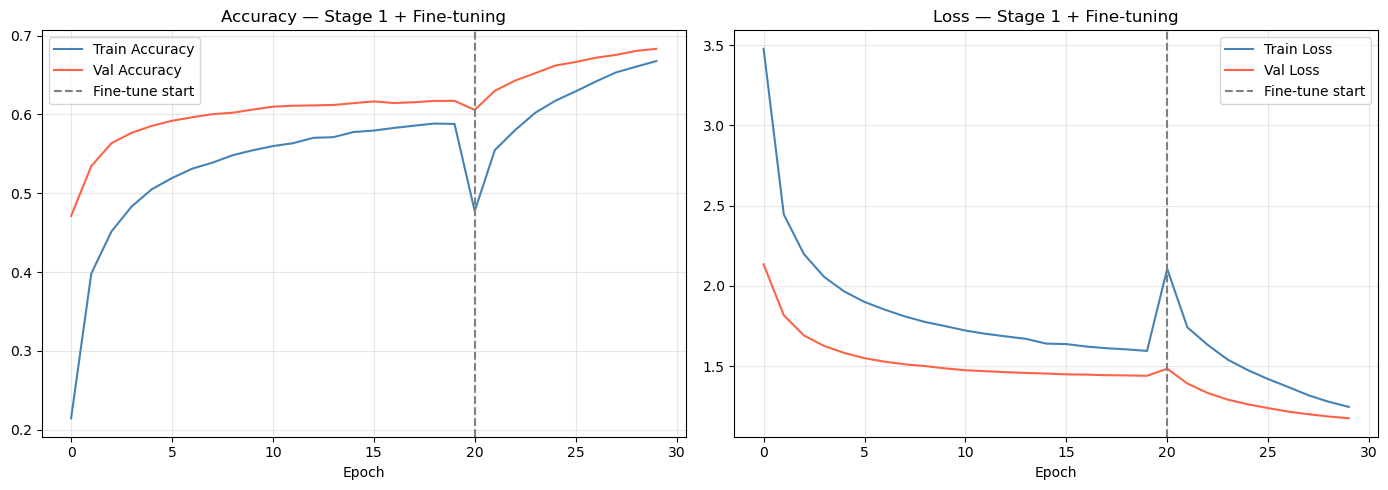

Saved: plots/04_finetuning_curves.png


In [21]:
# Plot combined training curves — Stage 1 + Stage 2 together
# This shows the full training history: initial fast gains from the frozen
# head training, then further improvement from fine-tuning
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

epochs_range = range(len(acc))
stage1_end = len(history.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc, label='Train Accuracy', color='steelblue')
axes[0].plot(epochs_range, val_acc, label='Val Accuracy', color='tomato')
axes[0].axvline(x=stage1_end, color='grey', linestyle='--', label='Fine-tune start')
axes[0].set_title('Accuracy — Stage 1 + Fine-tuning')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, loss, label='Train Loss', color='steelblue')
axes[1].plot(epochs_range, val_loss, label='Val Loss', color='tomato')
axes[1].axvline(x=stage1_end, color='grey', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss — Stage 1 + Fine-tuning')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_finetuning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/04_finetuning_curves.png')